In [2]:
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt

## Get the Data

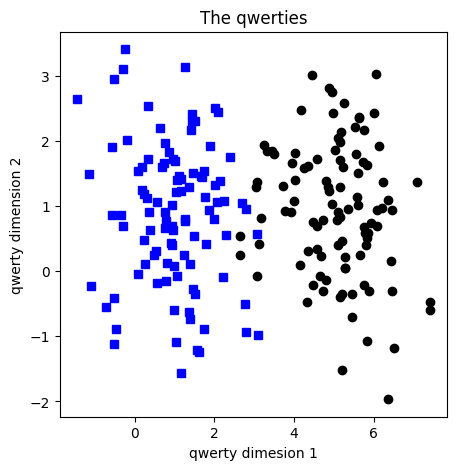

In [14]:
nPerClust = 100
blur = 1

A = [1, 1]
B = [5, 1]

a = [A[0]+np.random.randn(nPerClust)*blur, A[1]+np.random.randn(nPerClust)*blur]
b = [B[0]+np.random.randn(nPerClust)*blur, B[1]+np.random.randn(nPerClust)*blur]

labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

data_np = np.hstack((a,b)).T

data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties')
plt.xlabel('qwerty dimesion 1')
plt.ylabel('qwerty dimension 2')
plt.show()

## Build the Model

In [15]:
ANNclassify = nn.Sequential(
    nn.Linear(2,1), # input layer
    nn.ReLU(),  # activation unit
    nn.Linear(1,1),  # output unit
    nn.Sigmoid(),  # final activation unit
)

ANNclassify

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
  (3): Sigmoid()
)

## Model features

In [17]:
learningRate = 0.01

lossfun = nn.BCELoss()

optimizer = torch.optim.SGD(ANNclassify.parameters(), lr=learningRate)

## Train the Model

In [19]:
numepochs = 1000
losses = torch.zeros(numepochs)

for epochi in range(numepochs):

    # Forward pass
    yHat = ANNclassify(data)

    # Compute loss
    loss = lossfun(yHat, labels)
    losses[epochi] = loss

    # Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

## Losses

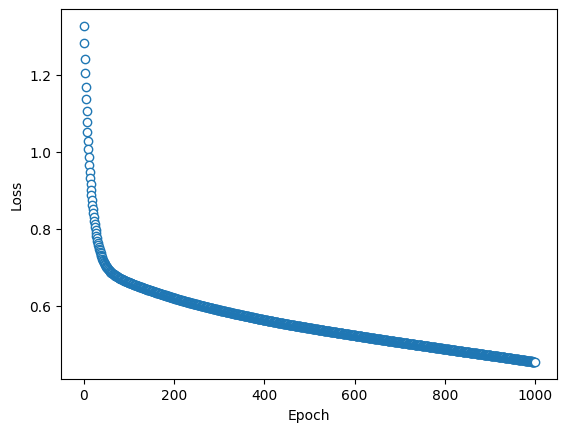

In [20]:
plt.plot(losses.detach(), 'o', markerfacecolor='w',linewidth=0.1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Predictions

In [26]:
predictions = ANNclassify(data)
predlabels = predictions>.5

misclassified = np.where(predlabels != labels)[0]

totalacc = 100-100*len(misclassified)/(2*nPerClust)

print("Final accuracy: %g%%" %totalacc)

Final accuracy: 83%
